# Memory-optimized time-lapse inversion example

Set `save_memory=True` in `inversion_params` to activate the sparse, lower-RAM solver path added to `TimeLapseERTInversion`. This notebook mirrors the main demo but keeps the run lightweight for quick checks.

In [4]:
import os
import sys
import time
import gc
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.physics import ert

# Setup package path for development
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from PyHydroGeophysX.inversion.time_lapse import TimeLapseERTInversion

try:
    import psutil
    PROC = psutil.Process()
except Exception as exc:
    PROC = None
    print("psutil not available; RSS memory numbers will be skipped.", exc)


In [5]:
data_dir = "results/TL_measurements/appres"
ert_files = [
    "synthetic_data30.dat",
    "synthetic_data60.dat",
    "synthetic_data90.dat",
    "synthetic_data120.dat",
]

# Use a short list for a fast smoke test; extend if you want the full 12-month run.
data_files = [os.path.join(data_dir, f) for f in ert_files]
measurement_times = list(range(1, len(data_files) + 1))

data = ert.load(data_files[0])
mesh = ert.ERTManager(data).createMesh(data=data, quality=34)

base_params = {
    "lambda_val": 10.0,
    "alpha": 10.0,
    "decay_rate": 0.0,
    "method": "cgls",
    "model_constraints": (0.001, 1e4),
    "max_iterations": 8,
    "absoluteUError": 0.0,
    "relativeError": 0.05,
    "lambda_rate": 1.0,
    "lambda_min": 1.0,
    "inversion_type": "L2",
}

def make_inversion(save_memory: bool):
    params = dict(base_params)
    params["save_memory"] = save_memory
    return TimeLapseERTInversion(
        data_files=data_files,
        measurement_times=measurement_times,
        mesh=mesh,
        **params
    )

def run_and_track(save_memory: bool):
    inv = make_inversion(save_memory)
    rss_before = PROC.memory_info().rss / 1e9 if PROC else None
    start = time.time()
    result = inv.run()
    gc.collect()
    rss_after = PROC.memory_info().rss / 1e9 if PROC else None
    stats = {
        "save_memory": save_memory,
        "rss_before_gb": rss_before,
        "rss_after_gb": rss_after,
        "delta_gb": (rss_after - rss_before) if (rss_before is not None and rss_after is not None) else None,
        "duration_s": time.time() - start,
    }
    return result, stats


16/01/26 - 17:01:51 - pyGIMLi - INFO - Found 2 regions.
16/01/26 - 17:01:51 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


In [6]:
print("Running save_memory=True ...")
result_save, stats_save = run_and_track(True)

print("Running save_memory=False ...")
result_dense, stats_dense = run_and_track(False)

def fmt_stats(stats):
    parts = []
    if stats.get("rss_before_gb") is not None:
        parts.append(f"before: {stats['rss_before_gb']:.2f} GB")
        parts.append(f"after: {stats['rss_after_gb']:.2f} GB")
        parts.append(f"delta: {stats['delta_gb']:.2f} GB")
    else:
        parts.append("RSS tracking unavailable (psutil missing).")
    parts.append(f"duration: {stats['duration_s']:.1f} s")
    return "; ".join(parts)

print("save_memory=True  ->", fmt_stats(stats_save))
print("save_memory=False ->", fmt_stats(stats_dense))


16/01/26 - 17:01:52 - pyGIMLi - INFO - Found 2 regions.
16/01/26 - 17:01:52 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
16/01/26 - 17:01:52 - pyGIMLi - INFO - Found 2 regions.
16/01/26 - 17:01:52 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
16/01/26 - 17:01:52 - pyGIMLi - INFO - Found 2 regions.
16/01/26 - 17:01:52 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
16/01/26 - 17:01:52 - pyGIMLi - INFO - Found 2 regions.
16/01/26 - 17:01:52 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
16/01/26 - 17:01:52 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/01/26 - 17:01:52 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/01/26 - 17:01:52 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3986 Cells: 7596 Boundaries: 5884


Running save_memory=True ...
-6.907755278982137 9.210340371976184
-------------------ERT Iteration: 0 ---------------------------


16/01/26 - 17:01:57 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/01/26 - 17:01:57 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/01/26 - 17:01:57 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3986 Cells: 7596 Boundaries: 5884
16/01/26 - 17:02:03 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/01/26 - 17:02:03 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/01/26 - 17:02:03 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3986 Cells: 7596 Boundaries: 5884
16/01/26 - 17:02:08 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/01/26 - 17:02:08 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/01/26 - 17:02:08 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3986 Cells: 7596 Boundaries: 5884


ERT chi2: 1198.146361714976
dPhi: 1.0
ERTphi_d: 3968260.75, ERTphi_m: 0.0, ERTphi_t: 0.0
-------------------ERT Iteration: 1 ---------------------------
ERT chi2: 48.04940368357488
dPhi: 0.9598968830362269
ERTphi_d: 159139.625, ERTphi_m: 2149.9655151367188, ERTphi_t: 2177.034149169922
-------------------ERT Iteration: 2 ---------------------------
ERT chi2: 15.682519295365339
dPhi: 0.6736167757951548
ERTphi_d: 51940.50390625, ERTphi_m: 785.7752990722656, ERTphi_t: 2175.3506469726562
-------------------ERT Iteration: 3 ---------------------------
ERT chi2: 3.7998052772116546
dPhi: 0.7577044092440803
ERTphi_d: 12584.955078125, ERTphi_m: 457.6343536376953, ERTphi_t: 2182.4679565429688
-------------------ERT Iteration: 4 ---------------------------
ERT chi2: 1.2244081358978713
dPhi: 0.6777708207204877
ERTphi_d: 4055.23974609375, ERTphi_m: 421.4490509033203, ERTphi_t: 2181.7022705078125
Convergence reached at iteration 4
End of inversion


16/01/26 - 17:03:55 - pyGIMLi - INFO - Found 2 regions.
16/01/26 - 17:03:55 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
16/01/26 - 17:03:55 - pyGIMLi - INFO - Found 2 regions.
16/01/26 - 17:03:55 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
16/01/26 - 17:03:55 - pyGIMLi - INFO - Found 2 regions.
16/01/26 - 17:03:55 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
16/01/26 - 17:03:55 - pyGIMLi - INFO - Found 2 regions.
16/01/26 - 17:03:55 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


Running save_memory=False ...


16/01/26 - 17:03:55 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/01/26 - 17:03:55 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/01/26 - 17:03:55 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3986 Cells: 7596 Boundaries: 5884


-6.907755278982137 9.210340371976184
-------------------ERT Iteration: 0 ---------------------------


16/01/26 - 17:04:01 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/01/26 - 17:04:01 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/01/26 - 17:04:01 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3986 Cells: 7596 Boundaries: 5884
16/01/26 - 17:04:06 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/01/26 - 17:04:06 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/01/26 - 17:04:06 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3986 Cells: 7596 Boundaries: 5884
16/01/26 - 17:04:12 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/01/26 - 17:04:12 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/01/26 - 17:04:12 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3986 Cells: 7596 Boundaries: 5884


ERT chi2: 1198.1465166389378
dPhi: 1.0
ERTphi_d: 3968261.263108162, ERTphi_m: 0.0, ERTphi_t: 0.0
-------------------ERT Iteration: 1 ---------------------------
ERT chi2: 48.049442882440836
dPhi: 0.9598968555054268
ERTphi_d: 159139.75482664406, ERTphi_m: 2149.9480814823155, ERTphi_t: 2176.9869247029383
-------------------ERT Iteration: 2 ---------------------------
ERT chi2: 15.654677375618235
dPhi: 0.6741964851929829
ERTphi_d: 51848.291468047595, ERTphi_m: 785.9124281611334, ERTphi_t: 2175.2881753059564
-------------------ERT Iteration: 3 ---------------------------
ERT chi2: 3.6942625109009954
dPhi: 0.7640154171011716
ERTphi_d: 12235.397436104096, ERTphi_m: 455.23343458911773, ERTphi_t: 2182.764738753818
-------------------ERT Iteration: 4 ---------------------------
ERT chi2: 1.2184148952342604
dPhi: 0.6701872453192016
ERTphi_d: 4035.39013301587, ERTphi_m: 421.36399893416353, ERTphi_t: 2182.0255969804907
Convergence reached at iteration 4
End of inversion
save_memory=True  -> before

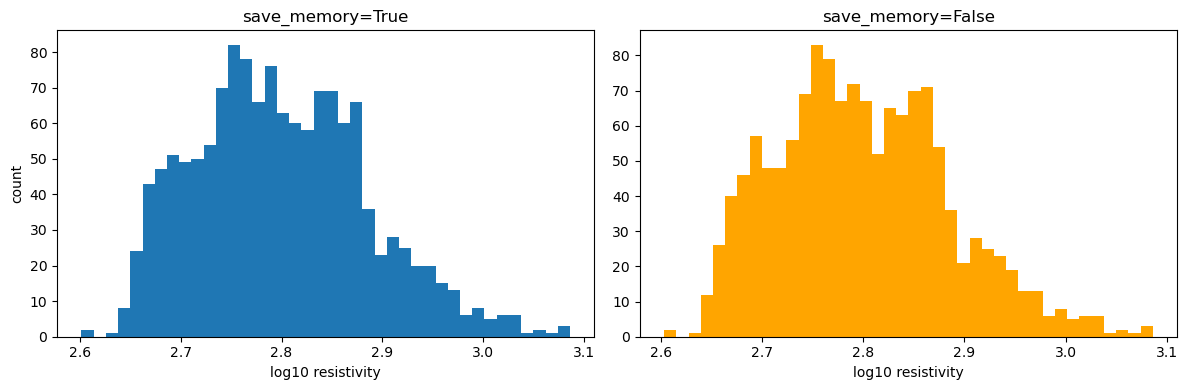

In [7]:
# Quick sanity check plot for both runs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if 'result_save' in globals() and getattr(result_save, 'final_models', None) is not None:
    axes[0].hist(np.log10(result_save.final_models[:, 0] + 1e-6), bins=40)
    axes[0].set_title("save_memory=True")
    axes[0].set_xlabel("log10 resistivity")
    axes[0].set_ylabel("count")
else:
    axes[0].text(0.5, 0.5, "No data", ha='center')
    axes[0].set_axis_off()

if 'result_dense' in globals() and getattr(result_dense, 'final_models', None) is not None:
    axes[1].hist(np.log10(result_dense.final_models[:, 0] + 1e-6), bins=40, color='orange')
    axes[1].set_title("save_memory=False")
    axes[1].set_xlabel("log10 resistivity")
else:
    axes[1].text(0.5, 0.5, "No data", ha='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()
